# Financial Simulator for Testing Various Models and Thresholds


In [1]:
import pandas as pd


cleaned_df = pd.read_csv("cleaned_df.csv", index_col=0)
print(len(cleaned_df))

391164


In [2]:
log_reg_preds = pd.read_csv("log_reg_predictions.csv", index_col=0)
rf_preds = pd.read_csv("rf_predictions.csv", index_col=0)
gb_preds = pd.read_csv("gb_predictions.csv", index_col=0)
print(len(log_reg_preds), len(rf_preds), len(gb_preds))

test_financials = cleaned_df.join(log_reg_preds, how="inner")
test_financials = test_financials.join(rf_preds[["rf_prob"]], how="inner")
test_financials = test_financials.join(gb_preds[["gb_prob"]], how="inner")

print(
    test_financials[
        ["loan_amnt", "total_pymnt", "net_pnl", "log_reg_prob", "rf_prob"]
    ].head()
)

78233 78233 78233
    loan_amnt   total_pymnt      net_pnl  log_reg_prob   rf_prob
2     20000.0  22705.924294  2705.924294      0.459988  0.186632
8     10000.0  10998.971575   998.971575      0.280916  0.061542
14    28000.0  29939.017729  1939.017729      0.211767  0.030997
28    17600.0  18305.080000   705.080000      0.164702  0.027709
30    16000.0  17396.630000  1396.630000      0.421265  0.196416


78233 78233
Profit if the bank approves everyone: $36,687,564.06
Crystal ball profit (if the bank approved every full-payer and rejected every defaulter): $144,171,901.10
Logistic Regression Peak Profit: $51,592,661.56 (at threshold 65.0%)
Random Forest Peak Profit: $51,829,322.29 (at threshold 35.0%)
Gradient Boosting Peak Profit: $53,522,433.17 (at threshold 31.0%)


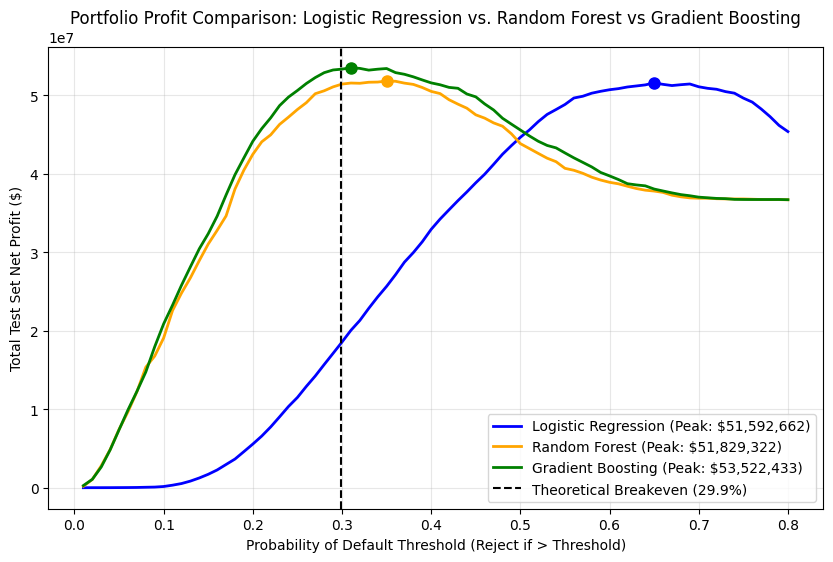

In [3]:
import matplotlib.pyplot as plt
import numpy as np

thresholds = np.linspace(0.01, 0.8, 80)
lr_profits = []
rf_profits = []
gb_profits = []

print(len(log_reg_preds), len(rf_preds))

print(f'Profit if the bank approves everyone: ${test_financials["net_pnl"].sum():,.2f}')
print(
    f"Crystal ball profit (if the bank approved every full-payer and rejected every defaulter): ${test_financials.loc[~test_financials['did_default'], 'net_pnl'].sum():,.2f}"
)

for t in thresholds:
    # -- Logistic Regression --
    lr_mask = log_reg_preds["log_reg_prob"] <= t
    lr_profit = test_financials["net_pnl"][lr_mask].sum()
    lr_profits.append(lr_profit)

    # -- Random Forest --
    rf_mask = rf_preds["rf_prob"] <= t
    rf_profit = test_financials["net_pnl"][rf_mask].sum()
    rf_profits.append(rf_profit)

    # -- Gradient Boosting --
    gb_mask = gb_preds["gb_prob"] <= t
    gb_profit = test_financials["net_pnl"][gb_mask].sum()
    gb_profits.append(gb_profit)

max_lr_profit = max(lr_profits)
best_lr_threshold = thresholds[lr_profits.index(max_lr_profit)]

max_rf_profit = max(rf_profits)
best_rf_threshold = thresholds[rf_profits.index(max_rf_profit)]

max_gb_profit = max(gb_profits)
best_gb_threshold = thresholds[gb_profits.index(max_gb_profit)]

print(
    f"Logistic Regression Peak Profit: ${max_lr_profit:,.2f} (at threshold {best_lr_threshold*100:.1f}%)"
)
print(
    f"Random Forest Peak Profit: ${max_rf_profit:,.2f} (at threshold {best_rf_threshold*100:.1f}%)"
)
print(
    f"Gradient Boosting Peak Profit: ${max_gb_profit:,.2f} (at threshold {best_gb_threshold*100:.1f}%)"
)

plt.figure(figsize=(10, 6))
plt.plot(
    thresholds,
    lr_profits,
    label=f"Logistic Regression (Peak: ${max_lr_profit:,.0f})",
    color="blue",
    linewidth=2,
)
plt.plot(
    thresholds,
    rf_profits,
    label=f"Random Forest (Peak: ${max_rf_profit:,.0f})",
    color="orange",
    linewidth=2,
)
plt.plot(
    thresholds,
    gb_profits,
    label=f"Gradient Boosting (Peak: ${max_gb_profit:,.0f})",
    color="green",
    linewidth=2,
)

plt.axvline(
    x=0.299, color="black", linestyle="--", label="Theoretical Breakeven (29.9%)"
)

plt.plot(best_lr_threshold, max_lr_profit, marker="o", color="blue", markersize=8)
plt.plot(best_rf_threshold, max_rf_profit, marker="o", color="orange", markersize=8)
plt.plot(best_gb_threshold, max_gb_profit, marker="o", color="green", markersize=8)

plt.title(
    "Portfolio Profit Comparison: Logistic Regression vs. Random Forest vs Gradient Boosting"
)
plt.xlabel("Probability of Default Threshold (Reject if > Threshold)")
plt.ylabel("Total Test Set Net Profit ($)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## Results and Discussion

There are a couple of things to discuss here.  
First, the Logistic Regression and Random Forest models each achieved similar profit peaks, though they had vastly different approval thresholds at their peaks. The maximum possible profit that could've been made was around $30M, and these models made around a third of that. And it was proven that the models are better than the foundational, naive strategy of just approving everyone, because that strategy made just $5M.

It is interesting to note that the Logistic Regression's peak profit was achieved at the threshold of 28.0%, because that's very close to the theoretically optimal cutoff of 29.9% that we calculated using expected value, with the idea that any borrower with a default probability of above 29.9% had a negative expected value. The possible reason the peak wasn't exactly on 29.9% could be because there are only 20% the same volume of loans in this dataset, and the distribution could be different compared to when we calculated that 29.9%.


before adding new columns of loan-to-income and payment-to-income:

Profit if the bank approves everyone: $5,075,169.18  
Crystal ball profit (if the bank approved every full-payer and rejected every defaulter): $30,026,176.63  
Logistic Regression Peak Profit: $10,364,610.55 (at threshold 64.0%)  
Random Forest Peak Profit: $10,461,409.24 (at threshold 28.0%)  
Gradient Boosting Peak Profit: $10,620,973.86 (at threshold 31.0%)


After adding new columns of loan-to-income and payment-to-income:  
Profit if the bank approves everyone: $5,075,169.18  
Crystal ball profit (if the bank approved every full-payer and rejected every defaulter): $30,026,176.63  
Logistic Regression Peak Profit: $10,237,940.00 (at threshold 63.0%)  
Random Forest Peak Profit: $10,435,380.32 (at threshold 28.0%)  
Gradient Boosting Peak Profit: $10,654,533.92 (at threshold 29.0%)


Now with 500k rows instead of 100k:
